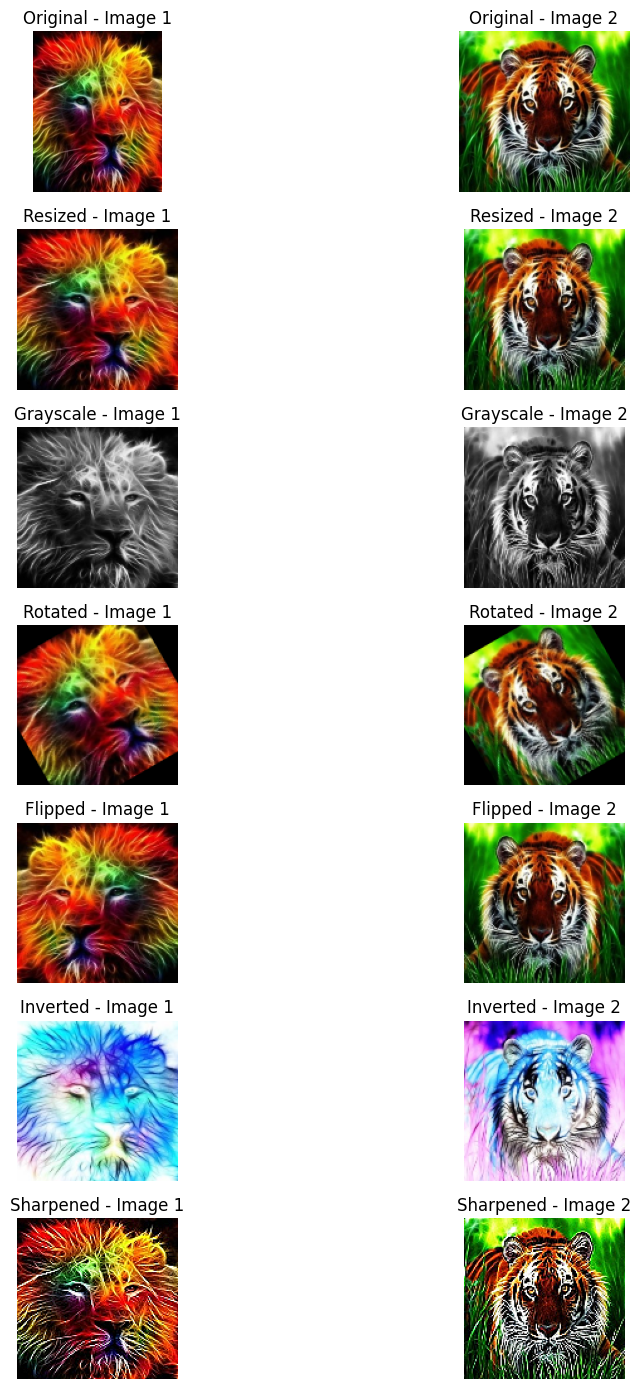

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img1 = cv2.imread("/kaggle/input/film-image/lion.jpg")
img2 = cv2.imread("/kaggle/input/film-image/tiger2.jpg")

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

resize1 = cv2.resize(img1, (128, 128))
resize2 = cv2.resize(img2, (128, 128))

gray1 = cv2.cvtColor(resize1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(resize2, cv2.COLOR_RGB2GRAY)

(h, w) = resize1.shape[:2]
center = (w // 2, h // 2)
matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
rotate1 = cv2.warpAffine(resize1, matrix, (w, h))
rotate2 = cv2.warpAffine(resize2, matrix, (w, h))

flip1 = cv2.flip(resize1, 1)
flip2 = cv2.flip(resize2, 1)

invert1 = cv2.bitwise_not(resize1)
invert2 = cv2.bitwise_not(resize2)

kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

sharp1 = cv2.filter2D(resize1, -1, kernel)
sharp2 = cv2.filter2D(resize2, -1, kernel)

titles = [
    "Original", "Resized", "Grayscale",
    "Rotated", "Flipped", "Inverted", "Sharpened"
]

images1 = [img1, resize1, gray1, rotate1, flip1, invert1, sharp1]
images2 = [img2, resize2, gray2, rotate2, flip2, invert2, sharp2]

plt.figure(figsize=(12, 14))

for i in range(len(images1)):
    plt.subplot(7, 2, 2*i+1)
    plt.imshow(images1[i], cmap='gray')
    plt.title(f"{titles[i]} - Image 1")
    plt.axis("off")

    plt.subplot(7, 2, 2*i+2)
    plt.imshow(images2[i], cmap='gray')
    plt.title(f"{titles[i]} - Image 2")
    plt.axis("off")

plt.tight_layout()
plt.show()


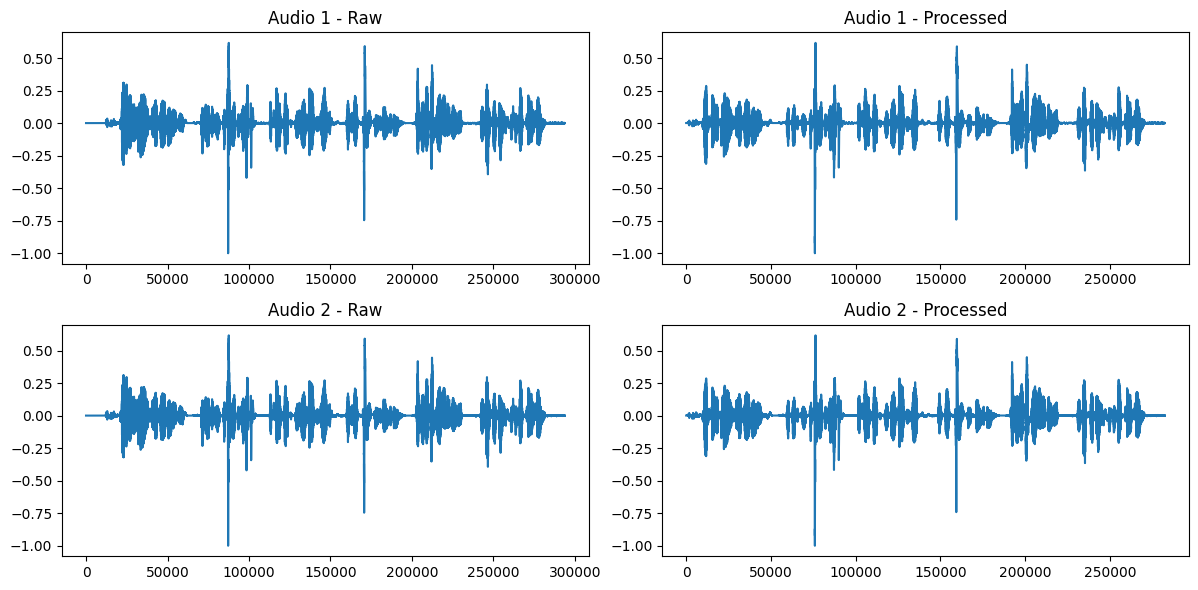

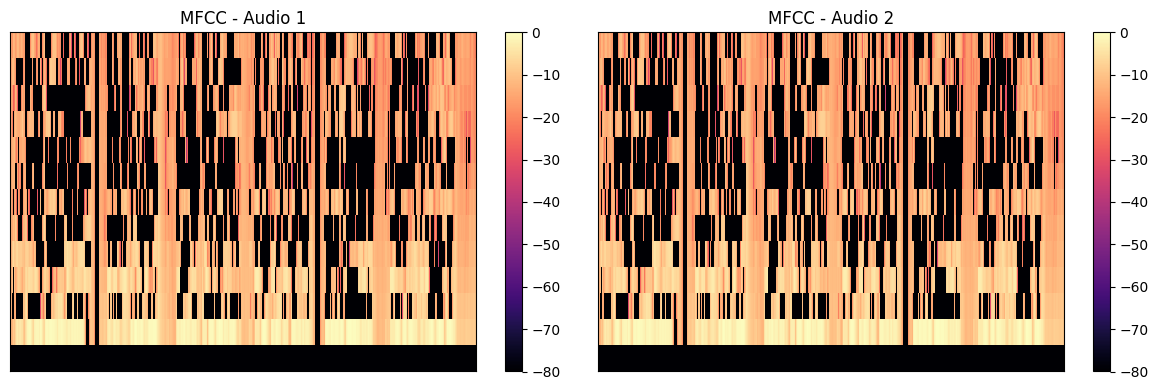

Final Features Tensor Shape: (2, 13, 552)


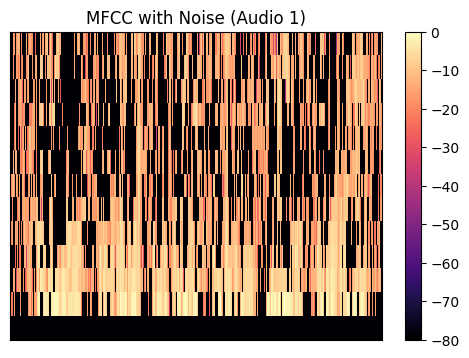

In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Low-pass filter
def lowpass_filter(signal, sr, cutoff=3000):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, signal)

# Add noise 
def add_noise(signal, noise_factor=0.02):
    noise = np.random.randn(len(signal))
    return signal + noise_factor * noise
    
# Load two audio samples
audio1, sr1 = librosa.load("/kaggle/input/viocedataset/harvard.wav", sr=None)
audio2, sr2 = librosa.load("/kaggle/input/viocedataset/harvard.wav", sr=None)

# Resample to 16 kHz
target_sr = 16000

audio1 = librosa.resample(y=audio1, orig_sr=sr1, target_sr=target_sr)
audio2 = librosa.resample(y=audio2, orig_sr=sr2, target_sr=target_sr)

sr = target_sr


# Normalize
audio1 = librosa.util.normalize(audio1)
audio2 = librosa.util.normalize(audio2)

# Silence trimming
audio1_trim, _ = librosa.effects.trim(audio1)
audio2_trim, _ = librosa.effects.trim(audio2)

# Optional low-pass filtering
audio1_filt = lowpass_filter(audio1_trim, sr)
audio2_filt = lowpass_filter(audio2_trim, sr)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.title("Audio 1 - Raw")
plt.plot(audio1)

plt.subplot(2, 2, 2)
plt.title("Audio 1 - Processed")
plt.plot(audio1_filt)

plt.subplot(2, 2, 3)
plt.title("Audio 2 - Raw")
plt.plot(audio2)

plt.subplot(2, 2, 4)
plt.title("Audio 2 - Processed")
plt.plot(audio2_filt)

plt.tight_layout()
plt.show()

mfcc1 = librosa.feature.mfcc(y=audio1_filt, sr=sr, n_mfcc=13)
mfcc2 = librosa.feature.mfcc(y=audio2_filt, sr=sr, n_mfcc=13)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.specshow(librosa.power_to_db(mfcc1, ref=np.max))
plt.title("MFCC - Audio 1")
plt.colorbar()

plt.subplot(1, 2, 2)
librosa.display.specshow(librosa.power_to_db(mfcc2, ref=np.max))
plt.title("MFCC - Audio 2")
plt.colorbar()

plt.tight_layout()
plt.show()
min_len = min(mfcc1.shape[1], mfcc2.shape[1])
mfcc1 = mfcc1[:, :min_len]
mfcc2 = mfcc2[:, :min_len]

features_tensor = np.stack([mfcc1, mfcc2])
print("Final Features Tensor Shape:", features_tensor.shape)

noisy_audio1 = add_noise(audio1)
noisy_trim, _ = librosa.effects.trim(noisy_audio1)
noisy_mfcc = librosa.feature.mfcc(y=noisy_trim, sr=sr, n_mfcc=13)

plt.figure(figsize=(6, 4))
librosa.display.specshow(librosa.power_to_db(noisy_mfcc, ref=np.max))
plt.title("MFCC with Noise (Audio 1)")
plt.colorbar()
plt.show()
